# functional Network Analysis as in Wang 2022  with Karin's hypothesis

detailed concepts of paper/analysis in `analysis_idea_overview.md`

Average `participation coefficient` PC for all nodes in each module was calculated to test which module drives the developmental-induced segregation effects. Further, `intra-connections` of each module and `inter-connections` between any two modules were calculated.
 
Code for PC: https://github.com/aestrivex/bctpy/blob/master/bct/algorithms/centrality.py

## State of analysis:

- all CM_parcel generated (36P)
- code for PC (entry for each parcel) there, intra/inter connnectivity just as summed over edges? (not )
- group comparison? mean over parcel in network... ?

In [1]:
import nibabel as nib
import numpy as np
import os
import pandas as pd

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numberline'

In [2]:
sub = 115
ses = 1
cm = np.load(os.path.join(bids_folder, 'derivatives', 'correlation_matrices.parcel', f'sub-{sub}_ses-{ses}_confspec-36P.npy'))  # generated with getCM_parcel.py

In [16]:
# from bct/algorithms/centrality.py

def participation_coef(W, ci, degree='undirected'):
    '''
    Participation coefficient is a measure of diversity of intermodular
    connections of individual nodes.

    Parameters
    ----------
    W : NxN np.ndarray
        binary/weighted directed/undirected connection matrix
    ci : Nx1 np.ndarray
        community affiliation vector
    degree : str
        Flag to describe nature of graph 'undirected': For undirected graphs
                                         'in': Uses the in-degree
                                         'out': Uses the out-degree

    Returns
    -------
    P : Nx1 np.ndarray
        participation coefficient
    '''
    if degree == 'in':
        W = W.T

    _, ci = np.unique(ci, return_inverse=True)
    ci += 1

    n = len(W)  # number of vertices
    Ko = np.sum(W, axis=1)  # (out) degree
    Gc = np.dot((W != 0), np.diag(ci))  # neighbor community affiliation - only edges within module/community
    
    Kc2 = np.zeros((n,))  # community-specific neighbors
    for i in range(1, int(np.max(ci)) + 1): # for each community, sum only the edges that are within that community
        Kc2 = Kc2 + np.square(np.sum(W * (Gc == i), axis=1))

    P = np.ones((n,)) - Kc2 / np.square(Ko) # divide
    #P = np.ones((n,)) - (Kc2 / np.square(Ko))  # divide
 
    # P=0 if for nodes with no (out) neighbors
    P[np.where(np.logical_not(Ko))] = 0

    return P


In [17]:
# sparsify the matrix
thresh_conn = 0.15  # Proportion of top connections to keep

def threshold_matrix(mat, proportion=thresh_conn):
    n = mat.shape[0]
    mat = mat.copy()
    np.fill_diagonal(mat, 0)     # Remove diagonal

    thresh = np.percentile(mat[mat > 0], 100 - 100 * proportion)     # Find threshold value
    mat[mat < thresh] = 0
    return mat

cm_sparse = threshold_matrix(cm)

In [18]:
from numrisk.fmri_analysis.gradients.utils import get_glasser_CAatlas_mapping
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()
ci = glasser_CAatlas_mapping['ca_network'].values
W = cm_sparse
part_coef = participation_coef(W, ci)

print(part_coef.shape)  # Should be (N_parcels,)

(360,)


/tmp/ipykernel_1159792/2401540438.py:38: RuntimeWarning: invalid value encountered in divide
  P = np.ones((n,)) - Kc2 / np.square(Ko) # divide


In [19]:
part_coef

array([0.14811415, 0.14281812, 0.71348017, 0.16891073, 0.12445982,
       0.12295372, 0.17440465, 0.2468498 , 0.34481197, 0.48023422,
       0.64060078, 0.58377194, 0.12783393, 0.33922378, 0.51985219,
       0.10078181, 0.60070661, 0.40379719, 0.2179721 , 0.21367331,
       0.23252456, 0.14322425, 0.        , 0.67216486, 0.39165168,
       0.73813999, 0.73131912, 0.62557315, 0.79749024, 0.37597184,
       0.60475041, 0.49640331, 0.43478124, 0.32527572, 0.32695594,
       0.72875154, 0.81582248, 0.80942486, 0.73612477, 0.27058154,
       0.52729311, 0.68019895, 0.51748815, 0.67516926, 0.82017853,
       0.63153043, 0.65338704, 0.50100285, 0.76886764, 0.70609381,
       0.21618766, 0.48206781, 0.33580716, 0.56370846, 0.13795897,
       0.65923479, 0.43879358, 0.45583894, 0.3160497 , 0.39533685,
       0.2084889 , 0.57135123, 0.63662795, 0.28776317, 0.36505107,
       0.33500113, 0.1714629 , 0.28567094, 0.4823442 , 0.68468964,
       0.17840596, 0.2710368 , 0.60483175, 0.68926371, 0.68624

In [10]:
# Degree of nodes
n = len(W)  # number of vertices
Ko = np.sum(W, axis=1)  # (out) degree


In [11]:
Gc = np.dot((W != 0), np.diag(ci))  # neighbor community affiliation - only edges within module/community
Gc.shape

(360, 360)

<Axes: >

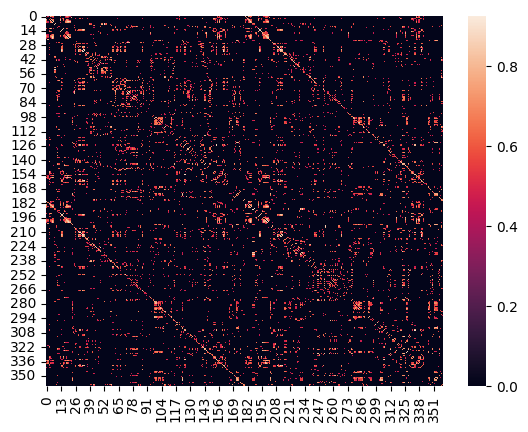

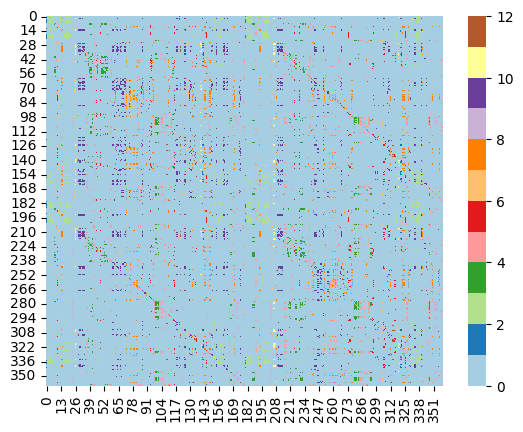

In [50]:
import seaborn as sns
sns.heatmap(W)
import matplotlib.pyplot as plt
plt.figure()

sns.heatmap(Gc, cmap='Paired')

In [51]:
Kc2 = np.zeros((n,))  # community-specific neighbors

for i in range(1, int(np.max(ci)) + 1):
    Kc2 = Kc2 + np.square(np.sum(W * (Gc == i), axis=1))

P = np.ones((n,)) - Kc2 / np.square(Ko)
# P=0 if for nodes with no (out) neighbors
P[np.where(np.logical_not(Ko))] = 0

/tmp/ipykernel_2665561/2179887520.py:6: RuntimeWarning: invalid value encountered in divide
  P = np.ones((n,)) - Kc2 / np.square(Ko)


In [52]:
Kc2

array([2.56599007e+02, 1.36763812e+02, 1.87762082e+02, 3.86112200e+02,
       2.58282556e+02, 2.72154740e+02, 2.70090653e+02, 8.59100384e+01,
       6.13436681e+01, 4.48700028e+01, 1.78416832e+02, 1.36043355e+02,
       2.12845152e+02, 4.19718912e+02, 2.33421426e+02, 3.36949721e+02,
       1.34933238e+02, 2.13724174e+02, 5.50484609e+02, 4.59496831e+02,
       3.05046012e+02, 1.28601563e+02, 1.99717889e+01, 1.42967841e+02,
       2.43127618e+01, 6.19777979e+01, 1.85076732e+02, 1.80694943e+01,
       9.00462961e+00, 4.26714462e+02, 4.19945706e+02, 1.88639849e+01,
       5.48336681e+02, 5.08691570e+02, 5.39312763e+02, 1.19720620e+01,
       5.61314900e+01, 1.26058129e+02, 2.57266615e+01, 2.87790397e+01,
       1.11079963e+02, 7.07237295e+01, 2.03865879e+02, 1.52516858e+02,
       4.53498076e+01, 5.69721248e+01, 3.82312810e+01, 5.04499704e+01,
       1.35543686e+01, 1.01135662e+02, 4.99260713e+01, 2.65121669e+01,
       6.44501265e+01, 7.12914988e+01, 3.39460406e+01, 4.39721983e+01,
      